<a href="https://colab.research.google.com/github/pras1978/fitness-journey-analyzer/blob/main/notebooks/03_pose_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/fitness-journey-analyzer/data"

print(os.listdir(BASE_PATH))

['cv', 'nlp', 'timeseries', 'processed']


In [ ]:
cv_path = os.path.join(BASE_PATH, "cv/workout_images")

print(os.listdir(cv_path))

['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raises', 'leg extension', 'leg raises', 'plank', 'pull up', 'push up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep dips', 'tricep pushdown']


Choose one sample image

In [ ]:
sample_class = os.listdir(cv_path)[0]
sample_folder = os.path.join(cv_path, sample_class)

image_file = os.listdir(sample_folder)[0]

image_path = os.path.join(sample_folder, image_file)

print(image_path)

/content/drive/MyDrive/fitness-journey-analyzer/data/cv/workout_images/barbell biceps curl/barbell biceps curl_3800031.jpg


Load and display image

(np.float64(-0.5), np.float64(479.5), np.float64(359.5), np.float64(-0.5))

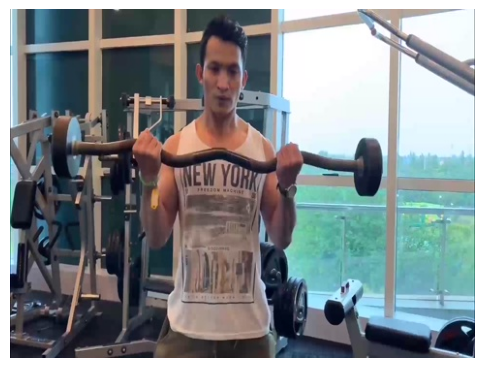

In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.axis("off")

Install MediaPipe

In [ ]:
!pip install tensorflow tensorflow-hub opencv-python

Import libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub

load MoveNet model

In [ ]:
model = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
movenet = model.signatures["serving_default"]

print("MoveNet loaded successfully")

MoveNet loaded successfully


load image

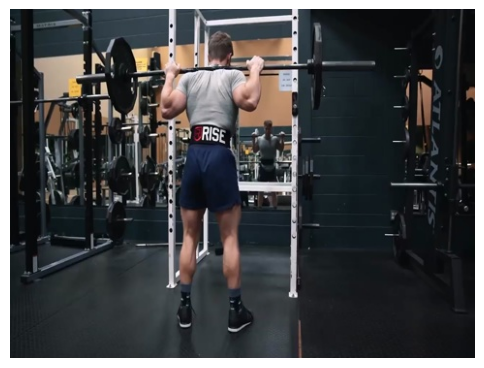

In [ ]:
image_path = "/content/drive/MyDrive/fitness-journey-analyzer/data/cv/workout_images/squat/squat_800091.jpg"

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

Step 4 — preprocess image for MoveNet

In [ ]:
input_size = 256

img = tf.image.resize_with_pad(tf.expand_dims(image_rgb, axis=0), input_size, input_size)
input_img = tf.cast(img, dtype=tf.int32)

results = movenet(input_img)
keypoints = results["output_0"].numpy()

print(keypoints.shape)

(1, 1, 17, 3)


Step 5 — inspect keypoints

In [ ]:
keypoints = keypoints[0, 0]

for i, kp in enumerate(keypoints):
    print(i, kp)

0 [0.22611554 0.4495776  0.43910486]
1 [0.20992637 0.44336617 0.40329787]
2 [0.21150985 0.4625984  0.5584187 ]
3 [0.22145234 0.42283034 0.63982564]
4 [0.22400141 0.468206   0.6412382 ]
5 [0.26572332 0.37466002 0.6658335 ]
6 [0.26469943 0.48343727 0.63011414]
7 [0.3408969  0.34760514 0.53466225]
8 [0.32294866 0.5136798  0.448407  ]
9 [0.28545475 0.35323814 0.61243546]
10 [0.26563513 0.5211943  0.55236465]
11 [0.45882177 0.39410967 0.80477583]
12 [0.46225694 0.45125842 0.71113557]
13 [0.59924805 0.3865148  0.79151464]
14 [0.613275  0.4675369 0.7779768]
15 [0.7245871  0.37612823 0.54396534]
16 [0.76487553 0.47621638 0.65400374]


Step 6 — draw keypoints on image

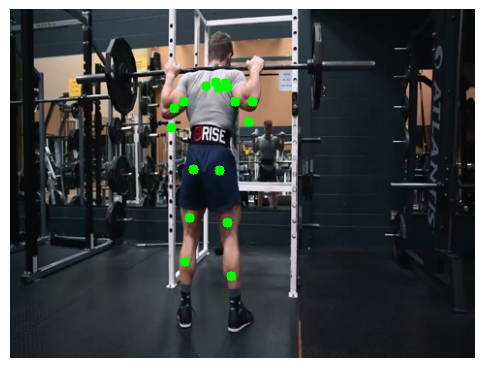

In [ ]:
KEYPOINT_DICT = {
    'nose': 0,
    'left_eye': 1,
    'right_eye': 2,
    'left_ear': 3,
    'right_ear': 4,
    'left_shoulder': 5,
    'right_shoulder': 6,
    'left_elbow': 7,
    'right_elbow': 8,
    'left_wrist': 9,
    'right_wrist': 10,
    'left_hip': 11,
    'right_hip': 12,
    'left_knee': 13,
    'right_knee': 14,
    'left_ankle': 15,
    'right_ankle': 16
}

display_img = image_rgb.copy()
h, w, _ = display_img.shape

for kp in keypoints:
    y, x, conf = kp
    if conf > 0.3:
        cx, cy = int(x * w), int(y * h)
        cv2.circle(display_img, (cx, cy), 5, (0, 255, 0), -1)

plt.figure(figsize=(6,6))
plt.imshow(display_img)
plt.axis("off")
plt.show()

Step 7 — angle calculation

In [ ]:
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians * 180.0 / np.pi)

    if angle > 180.0:
        angle = 360 - angle

    return angle

Step 8 — compute left knee angle

In [ ]:
left_hip = keypoints[KEYPOINT_DICT["left_hip"]][:2]
left_knee = keypoints[KEYPOINT_DICT["left_knee"]][:2]
left_ankle = keypoints[KEYPOINT_DICT["left_ankle"]][:2]

knee_angle = calculate_angle(left_hip, left_knee, left_ankle)

print("Left knee angle:", knee_angle)

Left knee angle: 178.35861


Step 9 — posture score

In [ ]:
ideal_knee_angle = 90

posture_score = max(0, 1 - abs(knee_angle - ideal_knee_angle) / ideal_knee_angle)

print("Posture score:", round(posture_score, 3))

Posture score: 0.018


Step 1 — display exercise + angle + posture score on image

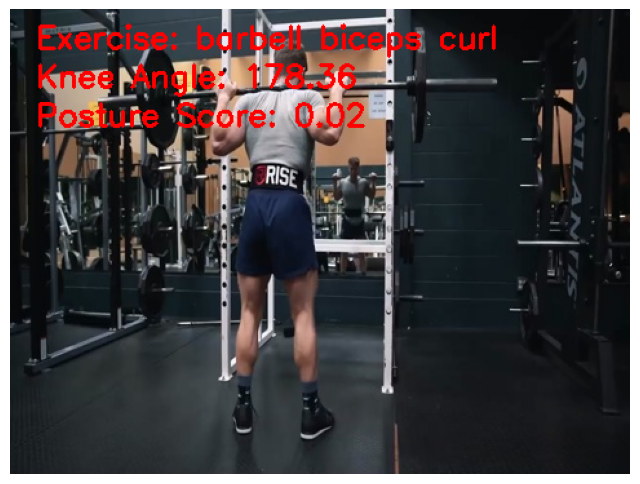

In [ ]:
display_img = image_rgb.copy()

text1 = f"Exercise: {sample_class}"
text2 = f"Knee Angle: {knee_angle:.2f}"
text3 = f"Posture Score: {posture_score:.2f}"

cv2.putText(display_img, text1, (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
cv2.putText(display_img, text2, (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
cv2.putText(display_img, text3, (20, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

plt.figure(figsize=(8,8))
plt.imshow(display_img)
plt.axis("off")
plt.show()

Step 2 — calculate more than one angle

Hip angle

In [ ]:
left_shoulder = keypoints[KEYPOINT_DICT["left_shoulder"]][:2]
left_hip = keypoints[KEYPOINT_DICT["left_hip"]][:2]
left_knee = keypoints[KEYPOINT_DICT["left_knee"]][:2]

hip_angle = calculate_angle(left_shoulder, left_hip, left_knee)
print("Hip angle:", hip_angle)

Hip angle: 171.15256


Elbow angle

In [ ]:
left_shoulder = keypoints[KEYPOINT_DICT["left_shoulder"]][:2]
left_elbow = keypoints[KEYPOINT_DICT["left_elbow"]][:2]
left_wrist = keypoints[KEYPOINT_DICT["left_wrist"]][:2]

elbow_angle = calculate_angle(left_shoulder, left_elbow, left_wrist)
print("Elbow angle:", elbow_angle)

Elbow angle: 13.9923115


Step 3 — make a better posture score

In [ ]:
ideal_knee = 90
ideal_hip = 100

knee_score = max(0, 1 - abs(knee_angle - ideal_knee) / ideal_knee)
hip_score = max(0, 1 - abs(hip_angle - ideal_hip) / ideal_hip)

posture_score_v2 = 0.6 * knee_score + 0.4 * hip_score
print("Improved posture score:", round(posture_score_v2, 3))

Improved posture score: 0.126


Step 4 — process multiple images, not just one

In [ ]:
sample_folder = os.path.join(cv_path, sample_class)
image_files = os.listdir(sample_folder)[:10]

results_list = []

for image_file in image_files:
    image_path = os.path.join(sample_folder, image_file)
    image = cv2.imread(image_path)

    if image is None:
        continue

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    img = tf.image.resize_with_pad(tf.expand_dims(image_rgb, axis=0), 256, 256)
    input_img = tf.cast(img, dtype=tf.int32)

    results = movenet(input_img)
    keypoints = results["output_0"].numpy()[0, 0]

    try:
        left_hip = keypoints[KEYPOINT_DICT["left_hip"]][:2]
        left_knee = keypoints[KEYPOINT_DICT["left_knee"]][:2]
        left_ankle = keypoints[KEYPOINT_DICT["left_ankle"]][:2]

        knee_angle = calculate_angle(left_hip, left_knee, left_ankle)
        posture_score = max(0, 1 - abs(knee_angle - 90) / 90)

        results_list.append({
            "image_file": image_file,
            "exercise": sample_class,
            "knee_angle": knee_angle,
            "posture_score": posture_score
        })
    except:
        continue

Step 5 — save results into a dataframe

In [ ]:
import pandas as pd

df_pose = pd.DataFrame(results_list)
df_pose.head()

,image_file,exercise,knee_angle,posture_score
0,barbell biceps curl_3800031.jpg,barbell biceps curl,75.025932,0.833622
1,barbell biceps curl_2200011.jpg,barbell biceps curl,16.251902,0.180577
2,barbell biceps curl_300001.jpg,barbell biceps curl,175.563248,0.049297
3,barbell biceps curl_4500291.jpg,barbell biceps curl,179.635086,0.004055
4,barbell biceps curl_1200111.jpg,barbell biceps curl,179.444977,0.006167


Step 6 — visualize posture score distribution

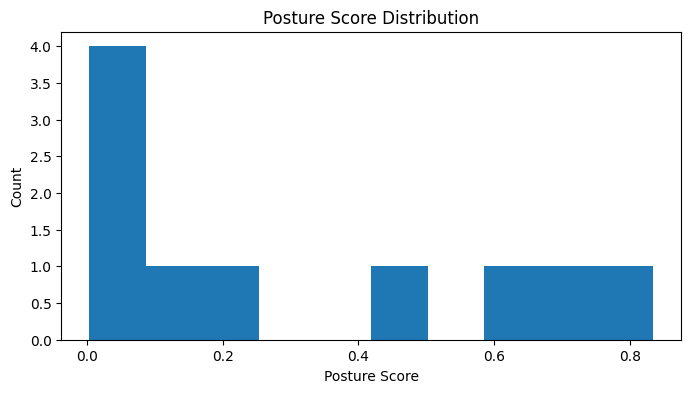

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df_pose["posture_score"], bins=10)
plt.title("Posture Score Distribution")
plt.xlabel("Posture Score")
plt.ylabel("Count")
plt.show()

Step 7 — save results for later use

In [ ]:
output_path = "/content/drive/MyDrive/fitness-journey-analyzer/data/processed/pose_scores_sample.csv"
df_pose.to_csv(output_path, index=False)
print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/fitness-journey-analyzer/data/processed/pose_scores_sample.csv
